# Import the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dirty_shipments.csv") #read the data

In [3]:
# View first 5 rows
df.head()

,shipment_id,origin_warehouse,destination_city,destination_state,carrier,ship_date,delivery_date,weight_kg,freight_cost,shipment_status,items_count,damage_reported
0,SHP-1001,Warehouse A,Dallas,TX,FastFreight,2024-01-10,2024-01-14,120.5,450.0,Delivered,48,No
1,SHP-1002,warehouse b,Los Angeles,CA,SPEEDYHAUL,2024-01-12,2024-01-11,85.3,320.0,delivered,30,no
2,SHP-1003,Warehouse A,Dallas,TX,FastFreight,2024-01-10,2024-01-14,120.5,450.0,Delivered,48,No
3,SHP-1004,Warehouse C,Chicago,il,FastFreight,01/15/2024,01/19/2024,200.0,610.0,In Transit,75,NaN
4,SHP-1005,warehouse a,Houston,TX,QuickShip,NaN,2024-01-20,-45.2,280.0,Delivered,20,Yes


# Basic information about data

In [4]:
df.shape

(25, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipment_id        25 non-null     str    
 1   origin_warehouse   25 non-null     str    
 2   destination_city   24 non-null     str    
 3   destination_state  25 non-null     str    
 4   carrier            25 non-null     str    
 5   ship_date          24 non-null     str    
 6   delivery_date      24 non-null     str    
 7   weight_kg          25 non-null     float64
 8   freight_cost       24 non-null     float64
 9   shipment_status    25 non-null     str    
 10  items_count        25 non-null     int64  
 11  damage_reported    22 non-null     str    
dtypes: float64(2), int64(1), str(9)
memory usage: 4.2 KB


In [6]:
df.describe()

,weight_kg,freight_cost,items_count
count,25.000000,24.000000,25.000000
mean,127.804000,1066.250000,45.920000
std,81.049833,2976.154234,30.206125
min,-45.200000,0.000000,-15.000000
25%,85.300000,320.000000,30.000000
50%,120.500000,455.000000,48.000000
75%,165.000000,592.500000,60.000000
max,310.800000,15000.000000,110.000000


# Data Cleaning

In [7]:
df["destination_state"] = df["destination_state"].str.upper().str.strip()

df["carrier"] = df["carrier"].str.title()

df["shipment_status"] = df["shipment_status"].str.title()

df["damage_reported"] = df["damage_reported"].str.title()

df["origin_warehouse"] = df["origin_warehouse"].str.title()

df["destination_city"] = df["destination_city"].str.title()


In [8]:
df.head()

,shipment_id,origin_warehouse,destination_city,destination_state,carrier,ship_date,delivery_date,weight_kg,freight_cost,shipment_status,items_count,damage_reported
0,SHP-1001,Warehouse A,Dallas,TX,Fastfreight,2024-01-10,2024-01-14,120.5,450.0,Delivered,48,No
1,SHP-1002,Warehouse B,Los Angeles,CA,Speedyhaul,2024-01-12,2024-01-11,85.3,320.0,Delivered,30,No
2,SHP-1003,Warehouse A,Dallas,TX,Fastfreight,2024-01-10,2024-01-14,120.5,450.0,Delivered,48,No
3,SHP-1004,Warehouse C,Chicago,IL,Fastfreight,01/15/2024,01/19/2024,200.0,610.0,In Transit,75,NaN
4,SHP-1005,Warehouse A,Houston,TX,Quickship,NaN,2024-01-20,-45.2,280.0,Delivered,20,Yes


# Check null values

In [9]:
df.isnull().sum()

shipment_id          0
origin_warehouse     0
destination_city     1
destination_state    0
carrier              0
ship_date            1
delivery_date        1
weight_kg            0
freight_cost         1
shipment_status      0
items_count          0
damage_reported      3
dtype: int64

# Fill missing categorical values

In [10]:
df["destination_city"] = df["destination_city"].fillna("Unknown")

df["damage_reported"] = df["damage_reported"].fillna("Unknown")


In [11]:
df.isnull().sum()

shipment_id          0
origin_warehouse     0
destination_city     0
destination_state    0
carrier              0
ship_date            1
delivery_date        1
weight_kg            0
freight_cost         1
shipment_status      0
items_count          0
damage_reported      0
dtype: int64

In [12]:

df["freight_cost"] = df["freight_cost"].fillna(df["freight_cost"].median())

#Convert Date Columns

In [13]:
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce")

# Handle Invalid Negative Values


In [14]:
df.loc[df["weight_kg"] < 0, "weight_kg"] = np.nan

df.loc[df["items_count"] < 0, "items_count"] = np.nan

In [15]:
# Fill missing numeric values using median

df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())

df["items_count"] = df["items_count"].fillna(df["items_count"].median())

# Feature Engineering

In [16]:
df["delivery_days"] = (df["delivery_date"] - df["ship_date"]).dt.days

In [17]:
df["cost_per_kg"] = df["freight_cost"] / df["weight_kg"]

In [18]:
df.head()

,shipment_id,origin_warehouse,destination_city,destination_state,carrier,ship_date,delivery_date,weight_kg,freight_cost,shipment_status,items_count,damage_reported,delivery_days,cost_per_kg
0,SHP-1001,Warehouse A,Dallas,TX,Fastfreight,2024-01-10,2024-01-14,120.5,450.0,Delivered,48.0,No,4.0,3.734440
1,SHP-1002,Warehouse B,Los Angeles,CA,Speedyhaul,2024-01-12,2024-01-11,85.3,320.0,Delivered,30.0,No,-1.0,3.751465
2,SHP-1003,Warehouse A,Dallas,TX,Fastfreight,2024-01-10,2024-01-14,120.5,450.0,Delivered,48.0,No,4.0,3.734440
3,SHP-1004,Warehouse C,Chicago,IL,Fastfreight,NaT,NaT,200.0,610.0,In Transit,75.0,Unknown,NaN,3.050000
4,SHP-1005,Warehouse A,Houston,TX,Quickship,NaT,2024-01-20,120.5,280.0,Delivered,20.0,Yes,NaN,2.323651


# Data Quality Checks

In [19]:
df[df["delivery_days"]<0]

,shipment_id,origin_warehouse,destination_city,destination_state,carrier,ship_date,delivery_date,weight_kg,freight_cost,shipment_status,items_count,damage_reported,delivery_days,cost_per_kg
1,SHP-1002,Warehouse B,Los Angeles,CA,Speedyhaul,2024-01-12,2024-01-11,85.3,320.0,Delivered,30.0,No,-1.0,3.751465


In [20]:
df[df["freight_cost"] > 5000]


,shipment_id,origin_warehouse,destination_city,destination_state,carrier,ship_date,delivery_date,weight_kg,freight_cost,shipment_status,items_count,damage_reported,delivery_days,cost_per_kg
15,SHP-1016,Warehouse B,Phoenix,AZ,Speedyhaul,2024-02-14,2024-02-19,95.0,15000.0,Delivered,35.0,Yes,5.0,157.894737


In [21]:
df[df["ship_date"].isnull()]

,shipment_id,origin_warehouse,destination_city,destination_state,carrier,ship_date,delivery_date,weight_kg,freight_cost,shipment_status,items_count,damage_reported,delivery_days,cost_per_kg
3,SHP-1004,Warehouse C,Chicago,IL,Fastfreight,NaT,NaT,200.0,610.0,In Transit,75.0,Unknown,NaN,3.050000
4,SHP-1005,Warehouse A,Houston,TX,Quickship,NaT,2024-01-20,120.5,280.0,Delivered,20.0,Yes,NaN,2.323651
7,SHP-1008,Warehouse C,Denver,CO,Fastfreight,NaT,NaT,150.0,520.0,Pending,55.0,No,NaN,3.466667
13,SHP-1014,Warehouse D,San Francisco,CA,Quickship,NaT,NaT,140.6,485.0,In Transit,52.0,No,NaN,3.449502
23,SHP-1024,Warehouse B,Los Angeles,CA,Speedyhaul,NaT,NaT,130.2,460.0,Delivered,50.0,No,NaN,3.533026


#  Exploratory Data Analysis (EDA)

In [22]:
df["freight_cost"].mean()


np.float64(1041.8)

In [23]:
# Maximum freight cost
df["freight_cost"].max()

15000.0

In [24]:
# Shipments per carrier
df["carrier"].value_counts()


carrier
Fastfreight    10
Quickship       8
Speedyhaul      7
Name: count, dtype: int64

In [25]:
df["delivery_days"].mean()


np.float64(4.473684210526316)

In [26]:
#which carrier is most expensive

df.groupby("carrier")["freight_cost"].mean().sort_values(ascending=False)

carrier
Speedyhaul     2452.142857
Fastfreight     525.000000
Quickship       453.750000
Name: freight_cost, dtype: float64

In [27]:
#Which carrier delivers fastest?

df.groupby("carrier")["delivery_days"].mean()

carrier
Fastfreight    4.0
Quickship      5.0
Speedyhaul     4.5
Name: delivery_days, dtype: float64

In [28]:
#count the origin_warehouse
df["origin_warehouse"].value_counts()

origin_warehouse
Warehouse A        7
Warehouse B        7
Warehouse C        5
Warehouse D        4
  Warehouse D      1
  Warehouse C      1
Name: count, dtype: int64

#  Data Visualization

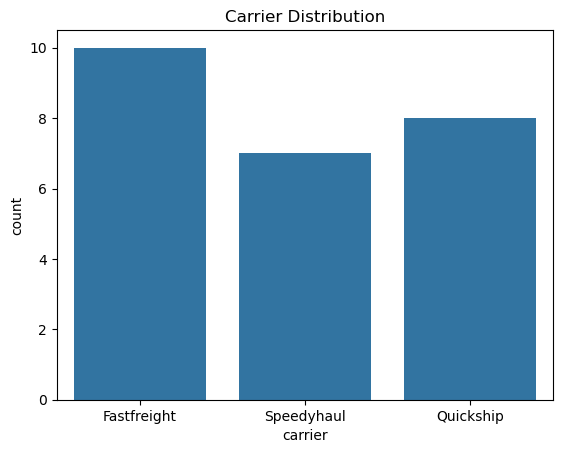

In [29]:
#plt.figure(figsize=(8,5))

sns.countplot(x="carrier", data=df)

plt.title("Carrier Distribution")

plt.show()

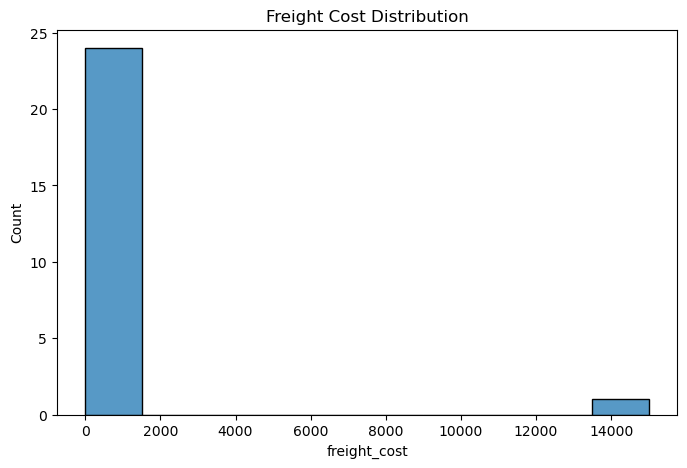

In [30]:

plt.figure(figsize=(8,5))

sns.histplot(df["freight_cost"], bins=10)

plt.title("Freight Cost Distribution")     # for check the distribution

plt.show()

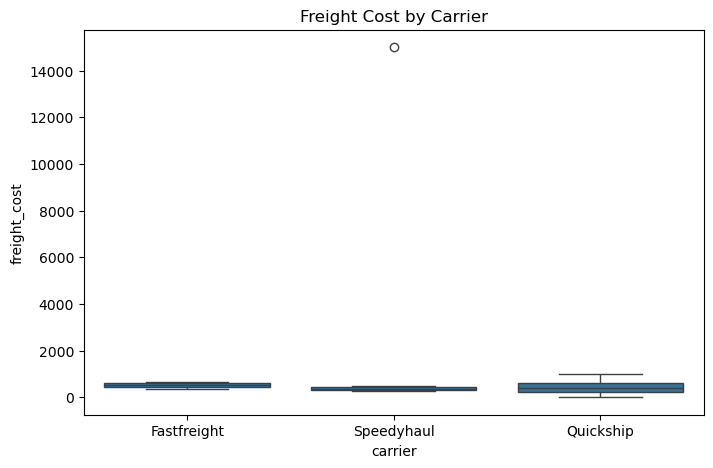

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x="carrier", y="freight_cost", data=df)

plt.title("Freight Cost by Carrier")    #for detect the outliers

plt.show()


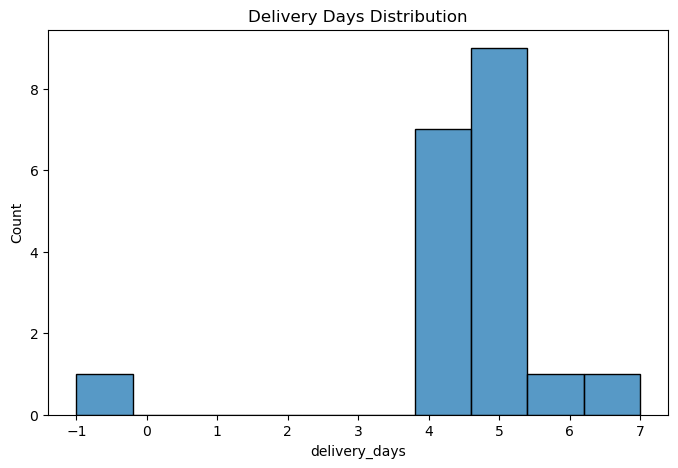

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["delivery_days"], bins=10)

plt.title("Delivery Days Distribution")      

plt.show()

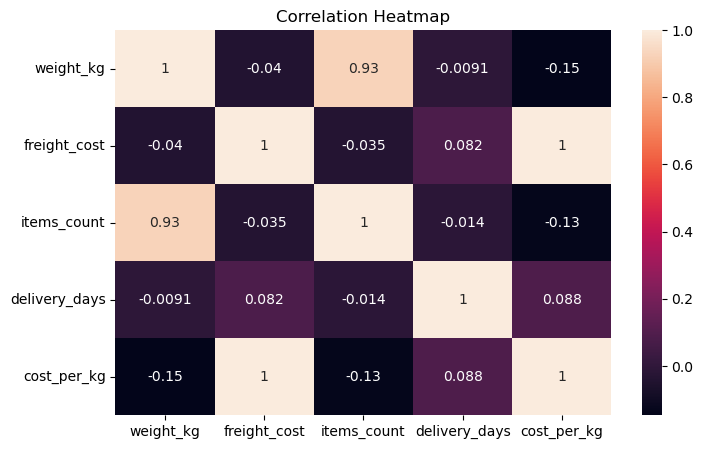

In [33]:
# Correlation Heatmap identify relationships between numerical variables such as freight cost, shipment weight, delivery days, and item count

plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True) 

plt.title("Correlation Heatmap")

plt.show()

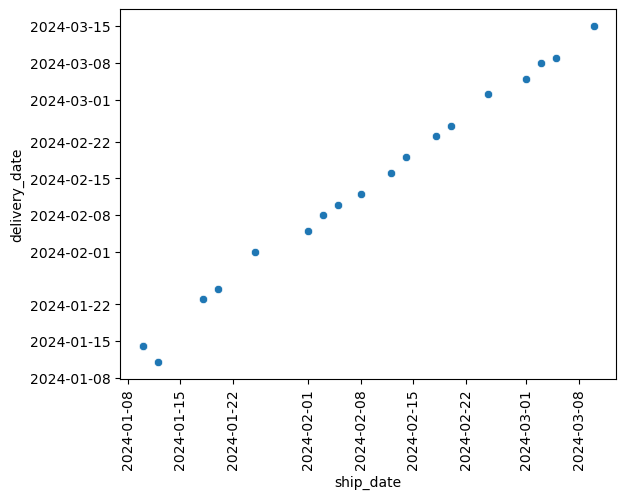

In [34]:
sns.scatterplot(x = "ship_date",y = "delivery_date",data=df)
plt.xticks(rotation=90)
plt.show()